This is a tutorial on how to use this 2D FMM RCWA code.

In [1]:
import RCWA_project.classes as classes
import RCWA_project.core as core

import numpy as np
import matplotlib.pyplot as plt

# Simple imports

Let's define the structure's parameters, as well as some computation variables:
- $M_m$ and $N_m$ are number of Fourier modes used in x and y directions respectively. These numbers can be quite low (~10) for simple (~2-4 interfaces) problems.
- $\eta$ is the stretching parameter

Here we will study the response of an array of a simple Metal-Insulator-Metal (MIM) resonator :

<img src="MIM.png" alt="MIM" width="500"/>

The necessary parameters are:
- height and width of the upper metallic part (the "cube")
- height of the spacer
- period in both directions (here they'll be the same)
- permittivity of the spacer (taken as a constant) and of the metal (varies with the wavelength)


In [2]:
# Computation parameters: nb of modes and stretching coefficient
mode = 10
eta = 0.999 # between 0 and 1 (but never exactly 1) Empirically, very close to 1 works really well

# Structure parameters: size of a MIM resonator
hcube = 40.0               # height of the cube
hspacer = 280.0            # height of the spacer
l_cubex = 2000.0           # cube width along axis x
l_cubey = 2000.0           # cube width along axis y
space_x = 5001-l_cubex     # period along x (RCWA nerd advice, never use an exactly round period)
space_y = 5002-l_cubey     # period along x (RCWA nerd advice, never use an exactly round period)

eps_dielec = 2.2**2        # spacer permittivity
metal_perm = "Gold"   # metal permittivity


Now let's define the structure itself. Each layer is defined by its interfaces in x and y, the permittivities and permeabilities of each zone.

More precisely, for each layer, we define:
- the interfaces along axis x and y (including the beginning and end of the period) (see image)
- Mm, Nm and eta as above
- the materials in each zone defined by the interfaces
- pmlx and pmly, 1 if the zones are supposed to be Perfectly Matched Layers. These work by axis, not by zone (see image)
- the thickness of each layer


<img src="zones.png" alt="zones" width="500"/>

And then we can directly define the Structure.

In [3]:
interfaces_x = [0, l_cubex, space_x+l_cubex]
interfaces_y = [0,l_cubey,l_cubey+space_y]
pmlx = [0,0]
pmly = [0,0]
pmls = [pmlx, pmly]
modes = [mode, mode]

Air = classes.Material(1.0)
dielec = classes.Material(eps_dielec)
Gold = classes.Material(metal_perm)

top = np.array([[Air,Air],
                  [Air,Air]])
spacer = np.array([[dielec,dielec],
                   [dielec, dielec]])
gp = np.array([[Gold,Air],
                [Air,Air]])
sub = np.array([[Gold,Gold],
                [Gold,Gold]])

layers = [top, gp, spacer, sub]
homo_layer = [1, 0, 1, 1]
thicknesses = [100, hcube, hspacer, 100]
interfaces = [interfaces_x, interfaces_y]
structure = classes.Structure(layers, thicknesses, interfaces, homo_layer, pmls)

We now need to define the incidence parameters:
- wavelength $\lambda$
- incidence angle (colatitude) $\theta$ of the wavevector k
- precession angle $\phi$, with $\phi = 0$ for k in the (x,z) plane
- polarisation (as a rotation around the wavevector, with pol=90 when the E field is parallel to the (x,y) plane (TE))


In [4]:

# Incidence parameters
lambdas = np.linspace(6000, 13000, 20) # Being a 3D simulation, each point in parameter space can take a few seconds on a reasonable computer

# Theta is the angle of incidence wrt the vertical z axis (theta = 0 is normal incidence)
theta = 0.0 * np.pi/180.
# Phi is how the incidence direction rotates around the vertical z axis
# (Phi = 0 is in the xOz plane, Phi = 90 is in the yOz place)
phi = 0.01 * np.pi/180. 
# Pol is how the fields are positioned around the incident wavevector (Pol = 0° is TM)
pol = 0*np.pi/180.

incidence = [theta, pol, phi]

## Clarifying incidence directions

Because we are in 2D, we need more angles to define the incidence condition :
- Theta will still be the colatitude (angle wrt the normal incidence)
- Phi will be the longitude (rotation around the vertical axis)
- delta, or pol, is how the fields rotate around the incidence direction
<img src="incidence_main.png" alt="defining incidence parameters" width="400"/>

**TM:**
<img src="incidence_00.png" alt="defining incidence parameters" width="300"/>
<img src="incidence_900.png" alt="defining incidence parameters" width="300"/>

**TE:**
<img src="incidence_090.png" alt="defining incidence parameters" width="300"/>
<img src="incidence_9090.png" alt="defining incidence parameters" width="300"/>

And then the main computation is done!

In [5]:
print(structure.int_x, structure.int_y)
rs = []
for i, lambd in enumerate(lambdas): # This is a 2D structure, so it might take a while
    print(lambd)
    R, T = core.coefficient_2D(structure, lambd, incidence, modes, eta)
    rs.append(R)


[0, 2000.0, 5001.0] [0, 2000.0, 5002.0]
6000.0
6368.421052631579
6736.842105263158
7105.263157894737
7473.684210526316
7842.105263157895
8210.526315789473
8578.947368421053
8947.368421052632
9315.78947368421
9684.21052631579
10052.631578947368
10421.052631578947
10789.473684210527
11157.894736842105
11526.315789473683
11894.736842105263
12263.157894736843
12631.578947368422
13000.0


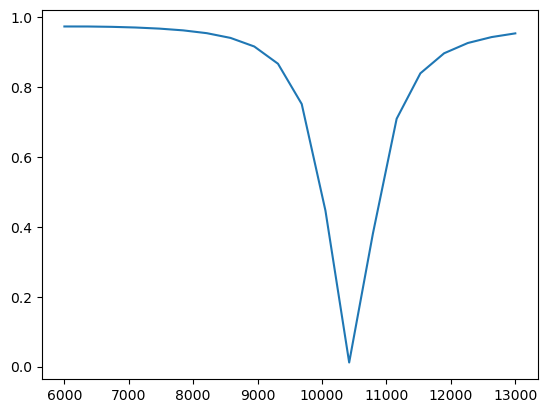

In [6]:
plt.plot(lambdas, rs)

## Pseudo 1D

This 2D mode can also model 1D structures! The trick is to define only one zone along y, and have 0 modes in y.

In the example below, we model a 70nm cube on a small gap, with PMLs (Perfectly Matched Layers, something that removes periodicity)

In [9]:
import RCWA_project.classes as classes
import RCWA_project.core as core

import numpy as np
import matplotlib.pyplot as plt

# Computation parameters: nb of modes and stretching coefficient
mode = 30
eta = 0.99 # between 0 and 1 (but never exactly 1) Empirically, very close to 1 works really well

# Structure parameters: size of a MIM resonator
hcube = 70.0               # height of the cube
hspacer = 1.0            # height of the spacer

l_cubex = 70.0           # cube width along axis x
periodx = 400.2
space_x = (periodx-l_cubex)/2      # period along x (RCWA nerd advice, never use an exactly round period)
space_pml = 70.23

# l_cubey = 1.04           # cube width along axis y
# periody = 2.13
# space_y = (periody-l_cubey)/2     # period along x (RCWA nerd advice, never use an exactly round period)

eps_dielec = 1.0**2        # spacer permittivity
metal_perm = "Gold"   # metal permittivity

interfaces_x = [0, space_x, space_x+l_cubex, 2*space_x+l_cubex, 2*space_x+l_cubex+space_pml]
interfaces_y = [0, 0.12]
pmlx = [0,0,0,1]
pmly = [0]
pmls = [pmlx, pmly]
modes = [mode, 0]

Air = classes.Material(1.0)
dielec = classes.Material(eps_dielec)
Gold = classes.Material(metal_perm)

top = np.array([[Air,Air,Air,Air]])
spacer = np.array([[dielec, dielec, dielec, dielec]])
gp = np.array([[Air, Gold,Air, Air]])
sub = np.array([[Gold,Gold,Gold,Gold]])

layers = [top, gp, spacer, sub]
homo_layer = [1, 0, 1, 1]
thicknesses = [100, hcube, hspacer, 100]
interfaces = [interfaces_x, interfaces_y]
structure = classes.Structure(layers, thicknesses, interfaces, homo_layer, pmls)

# Incidence parameters
lambdas = np.linspace(500, 1600.2, 100) # Being a 3D simulation, each point in parameter space can take a few seconds on a reasonable computer
theta = 0.0 * np.pi/180.
phi = 0.0 * np.pi/180.
pol = 0 * np.pi/180. # Pol 0° is TM
incidence = [theta, pol, phi]
print(structure.int_x, structure.int_y)
rs = []
ts = []

for i, lambd in enumerate(lambdas):
    print(f"lambda: {np.floor((i+1)/len(lambdas)*100)}%")
    R, T = core.coefficient_2D(structure, lambd, incidence, modes, eta)
    rs.append(R)
    ts.append(T)

[0, 165.1, 235.1, 400.2, 470.43] [0, 0.12]
lambda: 1.0%
lambda: 2.0%
lambda: 3.0%
lambda: 4.0%
lambda: 5.0%
lambda: 6.0%
lambda: 7.0%
lambda: 8.0%
lambda: 9.0%
lambda: 10.0%
lambda: 11.0%
lambda: 12.0%
lambda: 13.0%
lambda: 14.0%
lambda: 15.0%
lambda: 16.0%
lambda: 17.0%
lambda: 18.0%
lambda: 19.0%
lambda: 20.0%
lambda: 21.0%
lambda: 22.0%
lambda: 23.0%
lambda: 24.0%
lambda: 25.0%
lambda: 26.0%
lambda: 27.0%
lambda: 28.0%
lambda: 28.0%
lambda: 30.0%
lambda: 31.0%
lambda: 32.0%
lambda: 33.0%
lambda: 34.0%
lambda: 35.0%
lambda: 36.0%
lambda: 37.0%
lambda: 38.0%
lambda: 39.0%
lambda: 40.0%
lambda: 41.0%
lambda: 42.0%
lambda: 43.0%
lambda: 44.0%
lambda: 45.0%
lambda: 46.0%
lambda: 47.0%
lambda: 48.0%
lambda: 49.0%
lambda: 50.0%
lambda: 51.0%
lambda: 52.0%
lambda: 53.0%
lambda: 54.0%
lambda: 55.0%
lambda: 56.0%
lambda: 56.0%
lambda: 57.0%
lambda: 59.0%
lambda: 60.0%
lambda: 61.0%
lambda: 62.0%
lambda: 63.0%
lambda: 64.0%
lambda: 65.0%
lambda: 66.0%
lambda: 67.0%
lambda: 68.0%
lambda: 69.0%


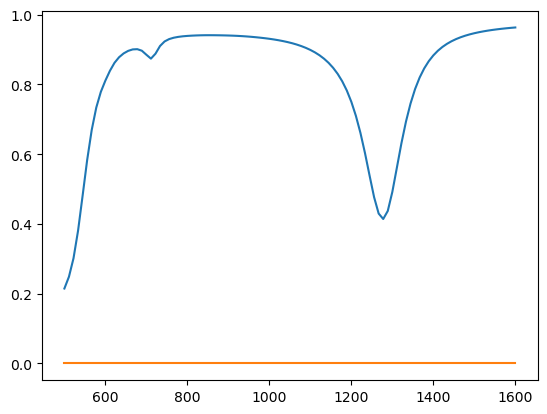

In [10]:
plt.plot(lambdas, rs)
plt.plot(lambdas, ts)